<a href="https://colab.research.google.com/github/mudassar2224/CNN_LENET-5.ipynb/blob/main/CNN_LENET_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q tensorflow tensorflow-datasets gradio opencv-python

# 🔹 **Cell 1 — Install Packages**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau)
from sklearn.utils import shuffle
import tensorflow_datasets as tfds

# 🔹 **Cell 3 — Load Datasets**

In [ ]:
# balanced = digits 0-9 + uppercase A-Z, ~112k samples, loads in ~2 min
ds_train = tfds.load('emnist/balanced', split='train', as_supervised=True)
ds_test  = tfds.load('emnist/balanced', split='test',  as_supervised=True)

x_train_raw, y_train_raw = [], []
x_test_raw,  y_test_raw  = [], []

for img, label in tfds.as_numpy(ds_train):
    x_train_raw.append(img)
    y_train_raw.append(label)

for img, label in tfds.as_numpy(ds_test):
    x_test_raw.append(img)
    y_test_raw.append(label)

x_train_raw = np.array(x_train_raw)
y_train_raw = np.array(y_train_raw)
x_test_raw  = np.array(x_test_raw)
y_test_raw  = np.array(y_test_raw)

print("Raw Train:", x_train_raw.shape)
print("Raw Test :", x_test_raw.shape)
print("Unique labels:", np.unique(y_train_raw))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/balanced/incomplete.GLNBR6_3.1.0/emnist-train.tfrecord*...:   0%|  …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/balanced/incomplete.GLNBR6_3.1.0/emnist-test.tfrecord*...:   0%|   …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/balanced/3.1.0. Subsequent calls will reuse this data.
Raw Train: (112800, 28, 28, 1)
Raw Test : (18800, 28, 28, 1)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]


# **Block 4 — Fix Orientation**

In [ ]:
def fix_orientation(x):
    x = x[:, :, :, 0]              # remove channel → (N,28,28)
    x = np.flip(x, axis=2)         # flip left-right ✅ confirmed correct
    return x[..., np.newaxis].copy()  # add channel back → (N,28,28,1)

x_train_raw = fix_orientation(x_train_raw)
x_test_raw  = fix_orientation(x_test_raw)
print("Orientation fixed:", x_train_raw.shape)

Orientation fixed: (112800, 28, 28, 1)


#  **Filter to 36 Classes Only (0–9 and A–Z)**

In [ ]:
# balanced has 47 classes — keep only 0-35 (digits + A-Z)
train_mask = y_train_raw <= 35
test_mask  = y_test_raw  <= 35

x_train = x_train_raw[train_mask]
y_train = y_train_raw[train_mask]
x_test  = x_test_raw[test_mask]
y_test  = y_test_raw[test_mask]

print("Train:", x_train.shape)
print("Test :", x_test.shape)
print("Label range:", y_train.min(), "to", y_train.max())

print("\n--- SANITY CHECK ---")
print("Digit labels  :", y_train[y_train <= 9][:5])
print("Letter labels :", y_train[y_train >= 10][:5])
# digits must be 0-9, letters must be 10-35

Train: (86400, 28, 28, 1)
Test : (14400, 28, 28, 1)
Label range: 0 to 35

--- SANITY CHECK ---
Digit labels  : [7 3 1 3 1]
Letter labels : [31 35 30 15 21]


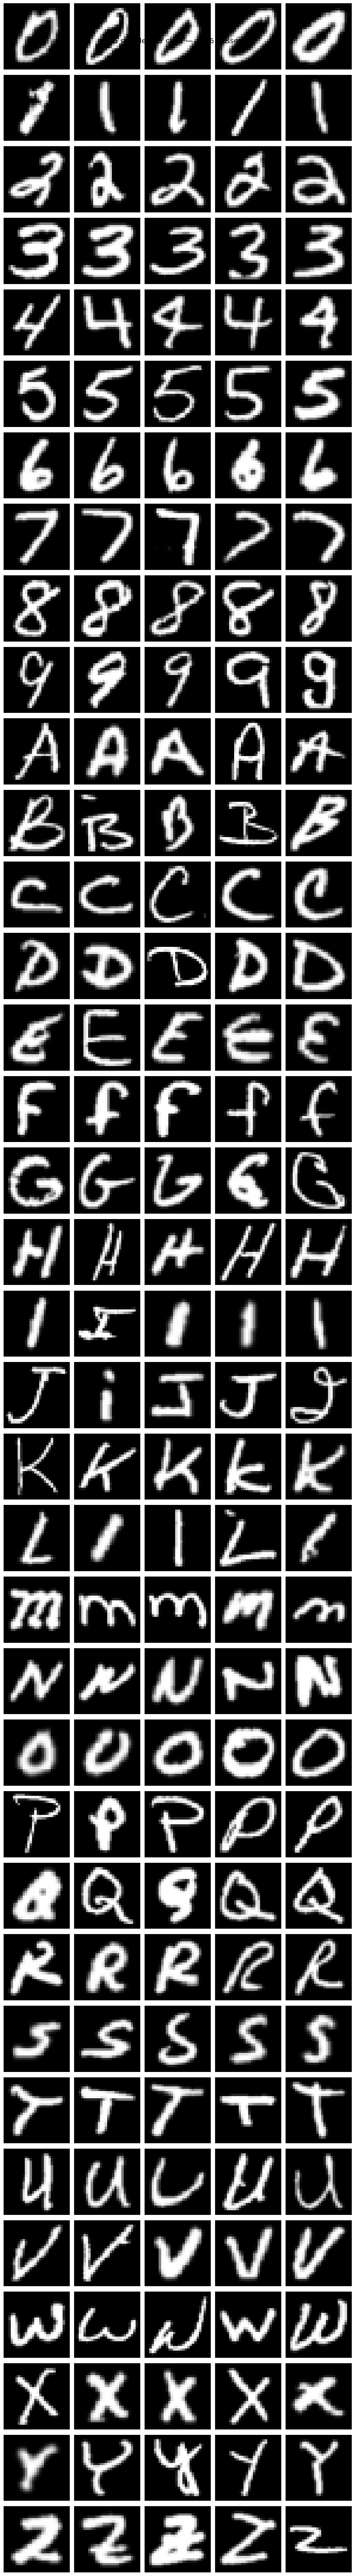

In [ ]:
# Check that letters look correct before training
classes_list = ['0','1','2','3','4','5','6','7','8','9',
                'A','B','C','D','E','F','G','H','I','J',
                'K','L','M','N','O','P','Q','R','S','T',
                'U','V','W','X','Y','Z']

# Show 5 random samples for each of the 36 classes
fig, axes = plt.subplots(36, 5, figsize=(10, 72))

for class_idx in range(36):
    # Find all samples of this class
    mask = y_train == class_idx
    samples = x_train[mask][:5]   # first 5 of this class

    for col in range(5):
        ax = axes[class_idx, col]
        if col < len(samples):
            ax.imshow(samples[col].squeeze(), cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(classes_list[class_idx], fontsize=12,
                         rotation=0, labelpad=20)

plt.suptitle("5 samples per class — all 36 classes", fontsize=14)
plt.tight_layout()
plt.show()

#  *Normalize*

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# **One-Hot Encode**

In [ ]:
y_train = to_categorical(y_train, 36)
y_test  = to_categorical(y_test,  36)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

y_train: (86400, 36)
y_test : (14400, 36)


# ✅ Build *LeNet-5* **Model**



```
𝑳𝒆𝑵𝒆𝒕 𝒇𝒍𝒐𝒘:  𝑰𝒎𝒂𝒈𝒆 → 𝑪𝒐𝒏𝒗 → 𝑷𝒐𝒐𝒍 → 𝑪𝒐𝒏𝒗 → 𝑷𝒐𝒐𝒍 → 𝑭𝒍𝒂𝒕𝒕𝒆𝒏 → 𝑫𝒆𝒏𝒔𝒆 → 𝑶𝒖𝒕𝒑𝒖𝒕  𝑪𝑵𝑵 𝒍𝒆𝒂𝒓𝒏𝒔:  𝒆𝒅𝒈𝒆𝒔 𝒔𝒕𝒓𝒐𝒌𝒆𝒔 𝒔𝒉𝒂𝒑𝒆𝒔 𝒅𝒊𝒈𝒊𝒕𝒔 𝒍𝒆𝒕𝒕𝒆𝒓𝒔
```



In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(36, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 36)             │         9,25

 Total params: 3,494,532 (13.33 MB)

 Trainable params: 3,492,868 (13.32 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 36)             │         9,25

 Total params: 3,494,532 (13.33 MB)

 Trainable params: 3,492,868 (13.32 MB)

 Non-trainable params: 1,664 (6.50 KB)

# **ℂ𝕠𝕞𝕡𝕚𝕝𝕖 𝕄𝕠𝕕𝕖𝕝**

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ 𝕋𝕣𝕒𝕚𝕟 𝕄𝕠𝕕𝕖𝕝  with Augmentation   Train with Callbacks

In [ ]:
# Shuffle and take 60% sample — enough data, much faster per epoch
x_s, y_s = shuffle(x_train, y_train, random_state=42)
n = int(len(x_s) * 0.6)
x_s, y_s = x_s[:n], y_s[:n]
print(f"Training on {x_s.shape[0]} samples")

datagen = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    datagen.flow(x_s, y_s, batch_size=256),
    validation_data=(x_test, y_test),
    epochs=20,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Training on 51840 samples
Epoch 1/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.3070 - loss: 2.7381
Epoch 1: val_accuracy improved from None to 0.02778, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step - accuracy: 0.4976 - loss: 1.7939 - val_accuracy: 0.0278 - val_loss: 7.3451 - learning_rate: 3.0000e-04
Epoch 2/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7386 - loss: 0.8006
Epoch 2: val_accuracy improved from 0.02778 to 0.17257, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - accuracy: 0.7602 - loss: 0.7270 - val_accuracy: 0.1726 - val_loss: 3.6123 - learning_rate: 3.0000e-04
Epoch 3/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8057 - loss: 0.5725
Epoch 3: val_accuracy improved from 0.17257 to 0.86000, saving model to best_model.keras

Epoch 3: finished saving model to best_model.ker

# ✅ *Evaluate*

In [ ]:
model = load_model('best_model.keras')
loss, acc = model.evaluate(x_test, y_test)
print(f"Best Model Test Accuracy: {acc*100:.2f}%")

450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9237 - loss: 0.2054
Best Model Test Accuracy: 92.37%


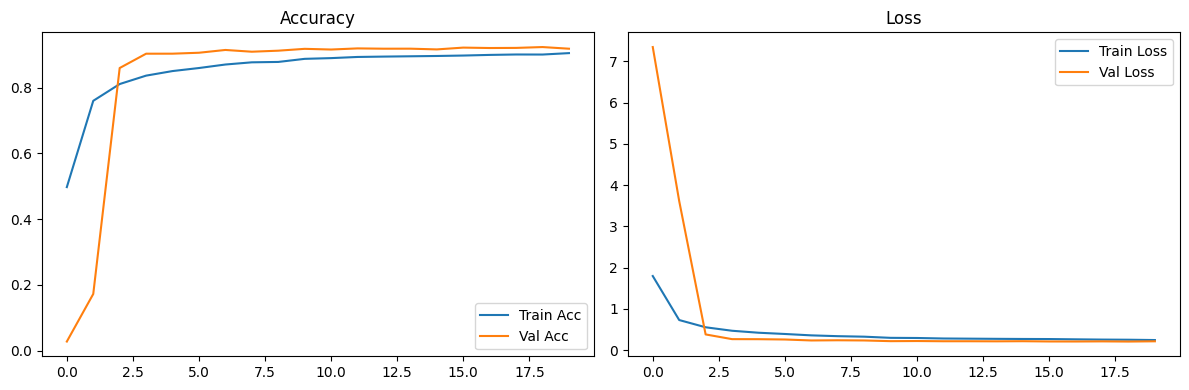

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import gradio as gr
import cv2
from tensorflow.keras.models import load_model

model = load_model('best_model.keras')

classes_list = ['0','1','2','3','4','5','6','7','8','9',
                'A','B','C','D','E','F','G','H','I','J',
                'K','L','M','N','O','P','Q','R','S','T',
                'U','V','W','X','Y','Z']

def preprocess(img):
    # Handle RGBA (Gradio draw) and RGB (uploaded photo)
    if len(img.shape) == 3:
        if img.shape[2] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    img = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)

    # White character on black background
    if np.mean(img) > 127:
        img = cv2.bitwise_not(img)

    _, img = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)

    img = img.astype("float32") / 255.0
    img = img.reshape(1, 28, 28, 1)
    return img

def predict(img):
    if img is None:
        return "Please draw or upload an image.", {}

    x = preprocess(img)
    pred = model.predict(x, verbose=0)[0]
    top5_idx = np.argsort(pred)[-5:][::-1]

    text, chart = "", {}
    for idx in top5_idx:
        label = classes_list[idx]
        prob  = float(pred[idx]) * 100
        text += f"{label} : {prob:.2f}%\n"
        chart[label] = prob

    return text, chart

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="numpy", label="Draw or Upload Character"),
    outputs=[
        gr.Textbox(label="Top Predictions"),
        gr.Label(label="Confidence")
    ],
    title="🔥 Digit + Alphabet Recognizer",
    description="Recognizes 0-9 and A-Z  |  Draw ONE character only, no text around it",
    theme="soft"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://78cdf90759a4895636.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Save in two formats — use whichever works
model.save('digit_alpha_model.keras')        # modern format
model.save('digit_alpha_model.h5')           # backup format

print("Model saved!")

# Also download it to your PC
from google.colab import files
files.download('digit_alpha_model.keras')

Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
size_mb = os.path.getsize('digit_alpha_model.keras') / (1024*1024)
print(f"Model size: {size_mb:.1f} MB")

Model size: 40.1 MB
